In [1]:
import sys
import os
# Adds the parent directory to sys.path
sys.path.append(os.path.abspath('..'))
import pandas as pd
from utils import (data_encoder, hyper_param_opt,
                   outlier_detection_by_clust,
                   weighted_distance_calculation,
                   outlier_detection_by_dist,
                   final_plot)
import pickle


In [2]:
def privgen(data, dataset_name):
    """
    This function exist just for development purposes
    In the actual tool, each of the steps of this functions are individual functions
    which should be ran consequently
    The plots that come out of this functions are those created by the intermediate steps
    and theretically speaking, should help the user to choose the parameters
    """

    # ENCODING
    # This is an auxilary function which is not done by the user
    encoded_data = data_encoder.ordinal_encode_categorical(
        data, dataset_name, save=True)

    # GRID-SEARCH
    hyper_param_opt.hyper_param_search(
        encoded_data,
        percentage_outliers=0.1,
        dataset_name=dataset_name,
        top_n=10,
        eps_values=[0.7, 0.8, 0.9, 1., 1.5, 2],
        min_samples_values=range(30, 50),
        save=True)

    # REMOVE DBSCAN OUTLIERS
    # The arguments of this funciton (now hard-coded) should be choosen by the user, 
    # based on the output of the previous step
    outlier_detection_by_clust.create_dbscan_and_clean_data(encoded_data, eps=2, min_samples=33,
                                                            metric='euclidean', algorithm='auto',
                                                            leaf_size=50, dataset_name=dataset_name, p=2, plot=False)

    # GET DISTRIBUTIONS
    weighted_distance_calculation.calculate_plot_distance(dataset_name)

    # REMOVE DISTANT OUTLIERS
    # The thresholds (now hard-coded) should be choosen by the user, 
    # based on the output of the previous step
    threshold = {'0': 30000, '1': 30000, '2': 30000, '3': 30000, '4': 30000, '5': 15000,
                 '6': 21000, '7': 25000, '8': 12000, '9': 25000, '10': 20000, '11': 20000, '12': 22000}

    outlier_detection_by_dist.filter_and_save_by_distance(
        dataset_name, threshold, plot=False)

    # PLOT
    final_plot.plot_data_points(dataset_name)

    # DECODING
    # This is an auxilary function which is not done by the user
    decoded_data = data_encoder.ordinal_decode_categorical(dataset_name)

    return decoded_data

In [15]:
 # as the name suggest this dataset was created just as a toy example
# inside privgen_generate.ipynb notebook you can find a funciton called download_dataset
# which can be used to download specific datasets from UCI database
data = pd.read_csv('../datasets/cervical-cancer_csv.csv')

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

## Imputation

In [17]:
from sklearn.impute import SimpleImputer

cols = data.columns
imp = SimpleImputer(strategy="most_frequent")
data = pd.DataFrame(imp.fit_transform(data))
data.columns = cols

## Encoding

In [19]:
dataset_name= 'cervical'
encoded_data = data_encoder.ordinal_encode_categorical(
        data, dataset_name, save=True)


Processing DBSCAN parameters:   1%|          | 187/21600 [00:01<01:33, 228.31it/s]

Mahalanobis distance cannot be used...


Processing DBSCAN parameters: 100%|██████████| 21600/21600 [06:50<00:00, 52.63it/s] 
/Users/navid/Documents/0_Research/0_venues/Privgen/utils/hyper_param_opt.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['ranking_score'] = (


,num_clusters,percentage_outliers,eps,min_samples,metric,algorithm,leaf_size,p,silhouette_score
18000,2,0.39521,2.0,30,euclidean,auto,10,NaN,0.059721
18208,2,0.39521,2.0,31,euclidean,ball_tree,50,1.0,0.059721
18207,2,0.39521,2.0,31,euclidean,ball_tree,50,NaN,0.059721
18206,2,0.39521,2.0,31,euclidean,ball_tree,40,2.0,0.059721
18205,2,0.39521,2.0,31,euclidean,ball_tree,40,1.0,0.059721
18204,2,0.39521,2.0,31,euclidean,ball_tree,40,NaN,0.059721
18203,2,0.39521,2.0,31,euclidean,ball_tree,30,2.0,0.059721
18202,2,0.39521,2.0,31,euclidean,ball_tree,30,1.0,0.059721
18201,2,0.39521,2.0,31,euclidean,ball_tree,30,NaN,0.059721
18200,2,0.39521,2.0,31,euclidean,ball_tree,20,2.0,0.059721


## DBSCAN HyperParameter Optimization

In [ ]:

    # GRID-SEARCH
hyper_param_opt.hyper_param_search(
    encoded_data,
    percentage_outliers=0.1,
    dataset_name=dataset_name,
    top_n=10,
    eps_values=[0.7, 0.8, 0.9, 1., 1.5, 2],
    min_samples_values=range(30, 50),
    save=True)

## REMOVE DBSCAN OUTLIERS



In [22]:
outlier_detection_by_clust.create_dbscan_and_clean_data(encoded_data, eps=2, min_samples=31,
                                                        metric='euclidean', algorithm='ball_tree',
                                                        leaf_size=50, dataset_name=dataset_name, p=1, plot=False)


Percentage of outliers removed: 39.52%
Number of clusters found: 2


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy,cluster
0,18.0,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,15.0,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34.0,1.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,42.0,3.0,23.0,2.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,27.0,1.0,17.0,3.0,0.0,0.0,0.0,1.0,8.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,43.0,3.0,17.0,3.0,0.0,0.0,0.0,1.0,5.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
501,34.0,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
502,32.0,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
503,33.0,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1



## GET DISTRIBUTIONS


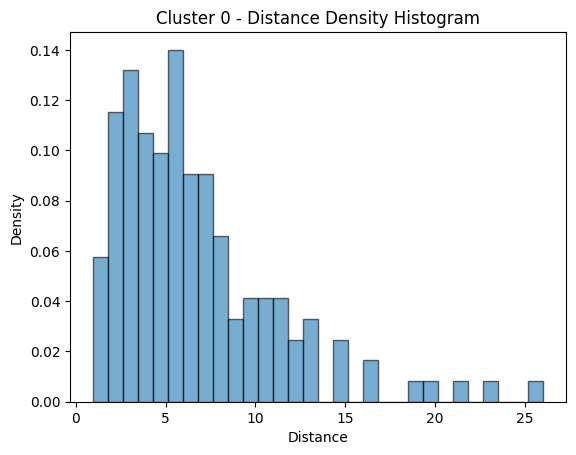

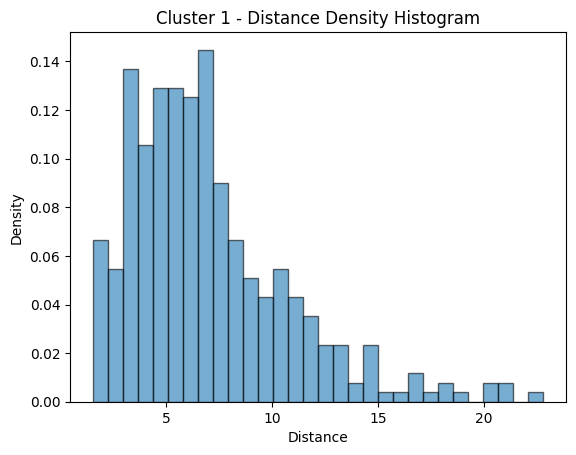

In [23]:
weighted_distance_calculation.calculate_plot_distance(dataset_name)



## REMOVE DISTANT OUTLIERS


In [24]:
threshold = {'0': 20, '1': 18}

outlier_detection_by_dist.filter_and_save_by_distance(
    dataset_name, threshold, plot=False)



## PLOT


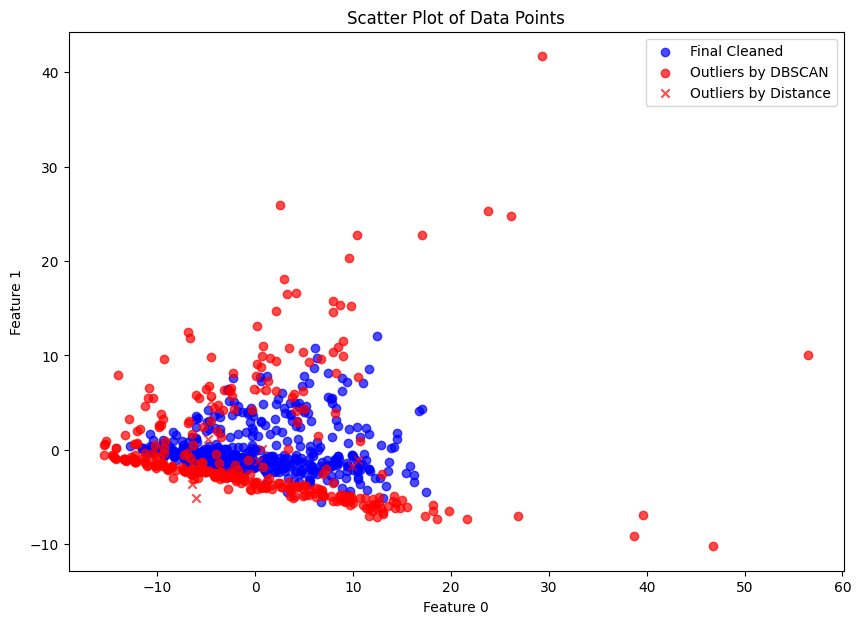

In [25]:
final_plot.plot_data_points(dataset_name)



## DECODING


In [26]:
decoded_data = data_encoder.ordinal_decode_categorical(dataset_name)